# Level 2 — Task 3: Clustering Analysis (K-Means)
**Codveda Technology | Data Analytics Internship**

> **Dataset:** `1_iris.csv` | **Tools:** Python, scikit-learn, matplotlib, seaborn
>
> **Objective:** Standardize the dataset, determine the optimal number of clusters using the elbow method, apply K-Means clustering, and visualize the clusters.


## Step 1 — Imports and Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
import warnings, os

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)

plt.rcParams.update({
    "figure.dpi": 120
})

os.makedirs("outputs/level2/clustering_plots", exist_ok=True)

CLUSTER_COLORS = {0: "#4CAF50", 1: "#2196F3", 2: "#FF5722"}
SPECIES_COLORS = {
    "setosa": "#4CAF50",
    "versicolor": "#2196F3",
    "virginica": "#FF5722"
}

print("Ready.")

Ready.


## Step 2 — Load and Standardize

In [3]:
df = pd.read_csv("1_iris.csv")
FEATURES = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
X = df[FEATURES].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dataset: {df.shape[0]} samples × {len(FEATURES)} features")
print(f"Post-scaling mean ≈ {X_scaled.mean():.4f}  std ≈ {X_scaled.std():.4f}")

Dataset: 150 samples × 4 features
Post-scaling mean ≈ -0.0000  std ≈ 1.0000


## Step 3 — Elbow Method (Optimal K)

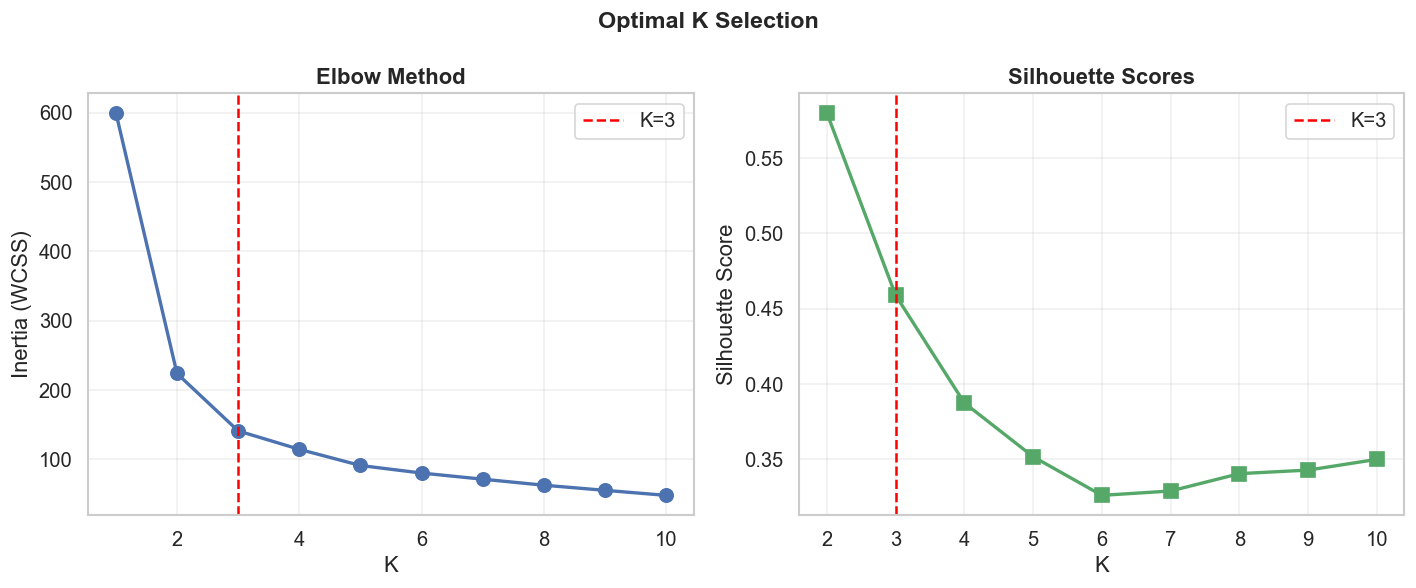

Optimal K = 3  (elbow inflection + highest silhouette score)


In [4]:
K_range = range(1, 11)
inertias, silhouette_scores = [], []

for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=20, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_) if k > 1 else np.nan)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Optimal K Selection", fontsize=14, fontweight="bold")

axes[0].plot(list(K_range), inertias, "bo-", lw=2, ms=8)
axes[0].axvline(3, color="red", ls="--", lw=1.5, label="K=3")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Method", fontweight="bold"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(list(K_range)[1:], silhouette_scores[1:], "gs-", lw=2, ms=8)
axes[1].axvline(3, color="red", ls="--", lw=1.5, label="K=3")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Scores", fontweight="bold"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/level2/clustering_plots/01_elbow_silhouette.png")
plt.show()
print("Optimal K = 3  (elbow inflection + highest silhouette score)")

## Step 4 — Fit Final K-Means Model (K=3)

In [5]:
kmeans = KMeans(n_clusters=3, init="k-means++", n_init=50, max_iter=300, random_state=42)
kmeans.fit(X_scaled)
df["Cluster"] = kmeans.labels_

sil = silhouette_score(X_scaled, kmeans.labels_)
print(f"Inertia          : {kmeans.inertia_:.4f}")
print(f"Silhouette score : {sil:.4f}")
print(f"\nCluster sizes:")
print(df["Cluster"].value_counts().sort_index())

centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids_orig, columns=FEATURES,
                            index=[f"Cluster {i}" for i in range(3)])
print("\nCluster centroids (original scale):")
centroid_df.round(3)

Inertia          : 140.9658
Silhouette score : 0.4590

Cluster sizes:
Cluster
0    53
1    50
2    47
Name: count, dtype: int64

Cluster centroids (original scale):


,sepal_length,sepal_width,petal_length,petal_width
Cluster 0,5.802,2.674,4.370,1.413
Cluster 1,5.006,3.418,1.464,0.244
Cluster 2,6.781,3.096,5.511,1.972


## Step 5 — 2D Scatter Visualization (Petal Space)

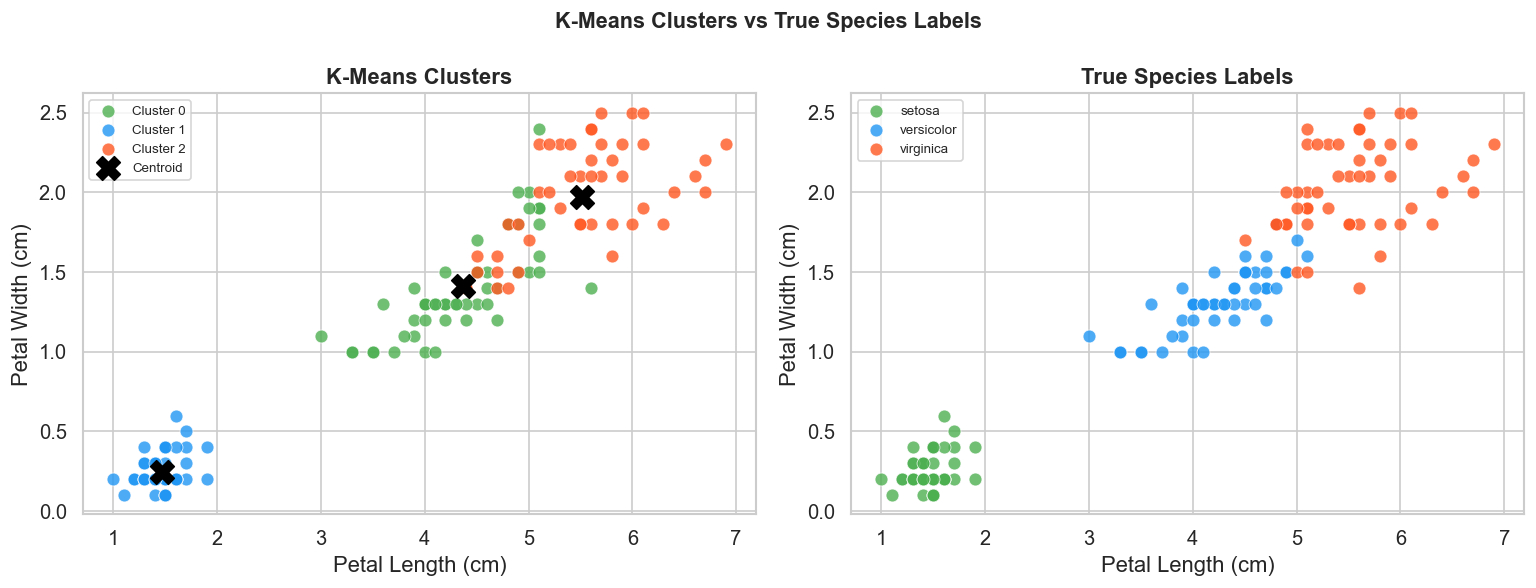

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("K-Means Clusters vs True Species Labels", fontsize=13, fontweight="bold")

# K-Means clusters
ax = axes[0]
for cid, color in CLUSTER_COLORS.items():
    mask = df["Cluster"] == cid
    ax.scatter(df.loc[mask,"petal_length"], df.loc[mask,"petal_width"],
               c=color, s=60, alpha=0.8, edgecolors="white", lw=0.5, label=f"Cluster {cid}")
cx = centroids_orig[:, FEATURES.index("petal_length")]
cy = centroids_orig[:, FEATURES.index("petal_width")]
ax.scatter(cx, cy, c="black", s=200, marker="X", zorder=5, label="Centroid")
ax.set_xlabel("Petal Length (cm)"); ax.set_ylabel("Petal Width (cm)")
ax.set_title("K-Means Clusters", fontweight="bold"); ax.legend(fontsize=8)

# True species
ax = axes[1]
for sp, color in SPECIES_COLORS.items():
    mask = df["species"] == sp
    ax.scatter(df.loc[mask,"petal_length"], df.loc[mask,"petal_width"],
               c=color, s=60, alpha=0.8, edgecolors="white", lw=0.5, label=sp)
ax.set_xlabel("Petal Length (cm)"); ax.set_ylabel("Petal Width (cm)")
ax.set_title("True Species Labels", fontweight="bold"); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("outputs/level2/clustering_plots/02_clusters_2d_petal.png")
plt.show()

## Step 6 — PCA 2D Projection

PC1 explains 72.8%  |  PC2 explains 23.0%  |  Total: 95.8%


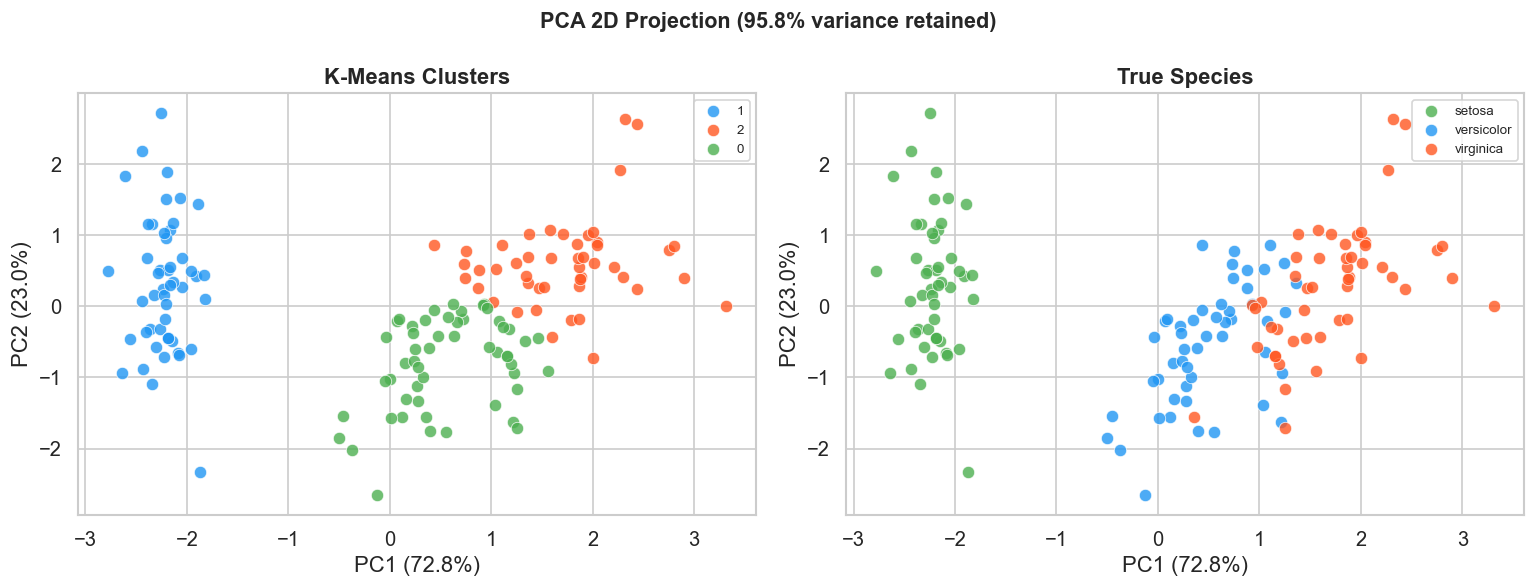

In [7]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var = pca.explained_variance_ratio_ * 100
print(f"PC1 explains {var[0]:.1f}%  |  PC2 explains {var[1]:.1f}%  |  Total: {sum(var):.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"PCA 2D Projection ({sum(var):.1f}% variance retained)", fontsize=13, fontweight="bold")

for ax, labels, cmap, title in [
    (axes[0], df["Cluster"],  CLUSTER_COLORS, "K-Means Clusters"),
    (axes[1], df["species"],  SPECIES_COLORS, "True Species"),
]:
    for lbl in labels.unique():
        mask = labels == lbl
        ax.scatter(X_pca[mask,0], X_pca[mask,1], c=cmap[lbl], s=55,
                   alpha=0.8, edgecolors="white", lw=0.5, label=str(lbl))
    ax.set_xlabel(f"PC1 ({var[0]:.1f}%)"); ax.set_ylabel(f"PC2 ({var[1]:.1f}%)")
    ax.set_title(title, fontweight="bold"); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("outputs/level2/clustering_plots/03_pca_projection.png")
plt.show()

## Step 7 — Cluster Agreement with True Labels

In [8]:
cross_tab = pd.crosstab(df["Cluster"], df["species"])
print("Cross-tabulation (Cluster × Species):")
print(cross_tab)

ari = adjusted_rand_score(pd.Categorical(df["species"]).codes, kmeans.labels_)
print(f"\nAdjusted Rand Index : {ari:.4f}  (1.0 = perfect, 0 = random)")
print(f"Silhouette Score    : {sil:.4f}  (closer to 1 = well-separated clusters)")

Cross-tabulation (Cluster × Species):
species  setosa  versicolor  virginica
Cluster                               
0             0          39         14
1            50           0          0
2             0          11         36

Adjusted Rand Index : 0.6201  (1.0 = perfect, 0 = random)
Silhouette Score    : 0.4590  (closer to 1 = well-separated clusters)
